# Coffee Dialling Automation — Regression Model
# Version 1

**Approach:** Supervised Regression Modelling  
**Target Variable:** `Overall`  
**Main Model:** Random Forest Regressor  
**Dataset:** CQI Arabica Coffee Quality Dataset  

---

## Purpose of Version 1

This notebook documents the **first regression approach** used in the Coffee Dialling Automation project.

The purpose of this version is to honestly show the original modelling workflow and explain why the model produced:

- a strong single train-test result, but
- negative 5-fold cross-validation results.

This version should be treated as the **initial experimental regression attempt**. It is useful because it reveals the limitations of the dataset and the weaknesses of the first validation approach.

---



# 1. Workflow Overview

The Version 1 workflow follows these steps:

1. Load the CQI Arabica dataset.
2. Inspect sensory score distributions.
3. Analyse correlations between sensory attributes and `Overall`.
4. Select relevant regression features.
5. Clean missing values and outliers.
6. Group rare categorical values.
7. Apply one-hot encoding.
8. Train a Random Forest Regressor.
9. Evaluate using a single train-test split.
10. Apply 5-fold cross-validation.
11. Compare multiple regression models.
12. Analyse why cross-validation produced negative values.

This version is important because it shows that a good single-split score alone is not enough evidence that a model generalises well.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Arabica.csv", encoding="latin1")

# Rename for easier handling
df = df.rename(columns={'Country/Region of Origin': 'Country'})

print("Shape:", df.shape)

print("\nSensory columns check:")
sensory = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Overall']
for col in sensory:
    print(f"  {col} — present: {col in df.columns}")

print("\nSensory score summary:")
print(df[sensory].describe().round(2))

Shape: (207, 37)

Sensory columns check:
  Aroma — present: True
  Flavor — present: True
  Aftertaste — present: True
  Acidity — present: True
  Body — present: True
  Balance — present: True
  Overall — present: True

Sensory score summary:
        Aroma  Flavor  Aftertaste  Acidity    Body  Balance  Overall
count  207.00  207.00      207.00   207.00  207.00   207.00   207.00
mean     7.72    7.74        7.60     7.69    7.64     7.64     7.68
std      0.29    0.28        0.28     0.26    0.23     0.26     0.31
min      6.50    6.75        6.67     6.83    6.83     6.67     6.67
25%      7.58    7.58        7.42     7.50    7.50     7.50     7.50
50%      7.67    7.75        7.58     7.67    7.67     7.67     7.67
75%      7.92    7.92        7.75     7.88    7.75     7.79     7.92
max      8.58    8.50        8.42     8.58    8.25     8.42     8.58


## Step 2: Distribution of Sensory Scores

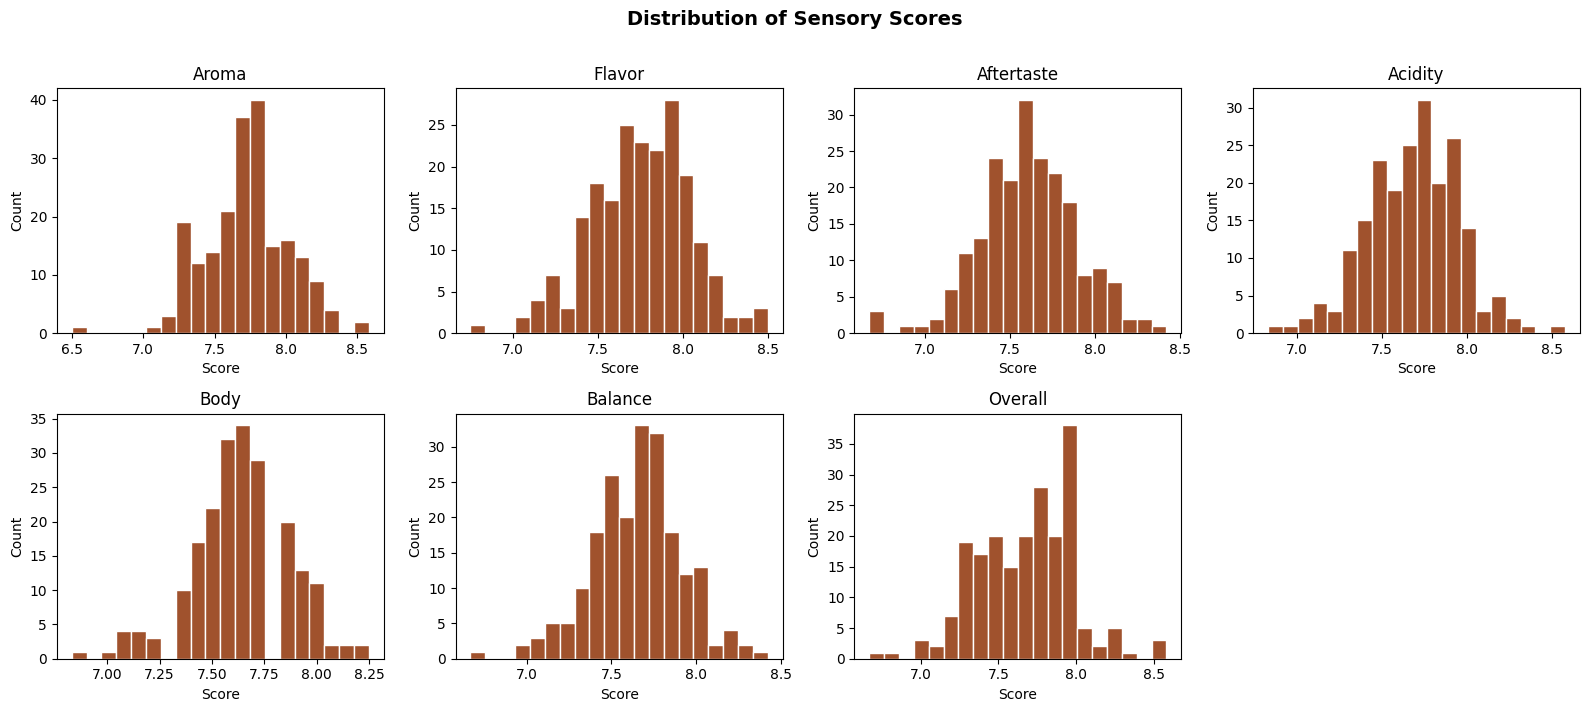

In [ ]:
sensory = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Overall']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(sensory):
    axes[i].hist(df[col], bins=20, color='sienna', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')

# Hide the empty 8th subplot
axes[7].set_visible(False)

plt.suptitle('Distribution of Sensory Scores', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 3: Correlation Between Sensory Scores

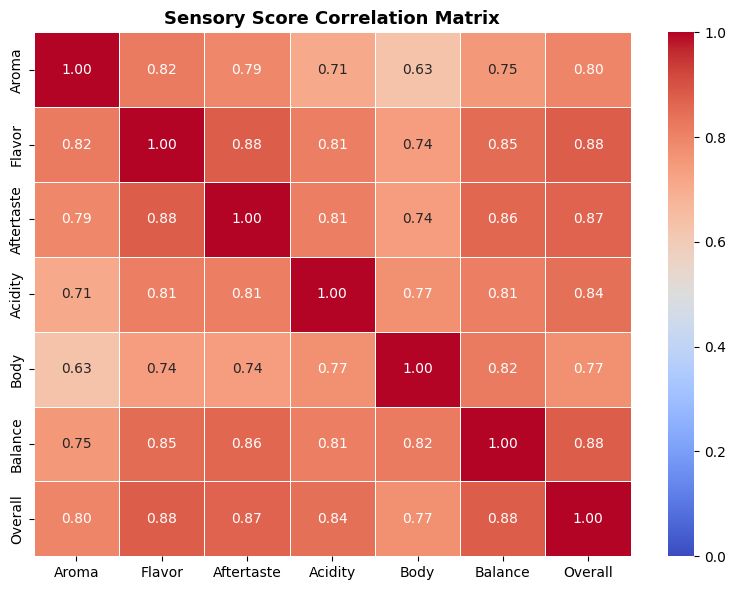


Correlation with Overall (sorted):
Flavor        0.88
Balance       0.88
Aftertaste    0.87
Acidity       0.84
Aroma         0.80
Body          0.77
Name: Overall, dtype: float64


In [ ]:
sensory = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Overall']

corr_matrix = df[sensory].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title('Sensory Score Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Overall (sorted):")
print(corr_matrix['Overall'].drop('Overall').sort_values(ascending=False))

## Step 4: Average Overall Score by Country

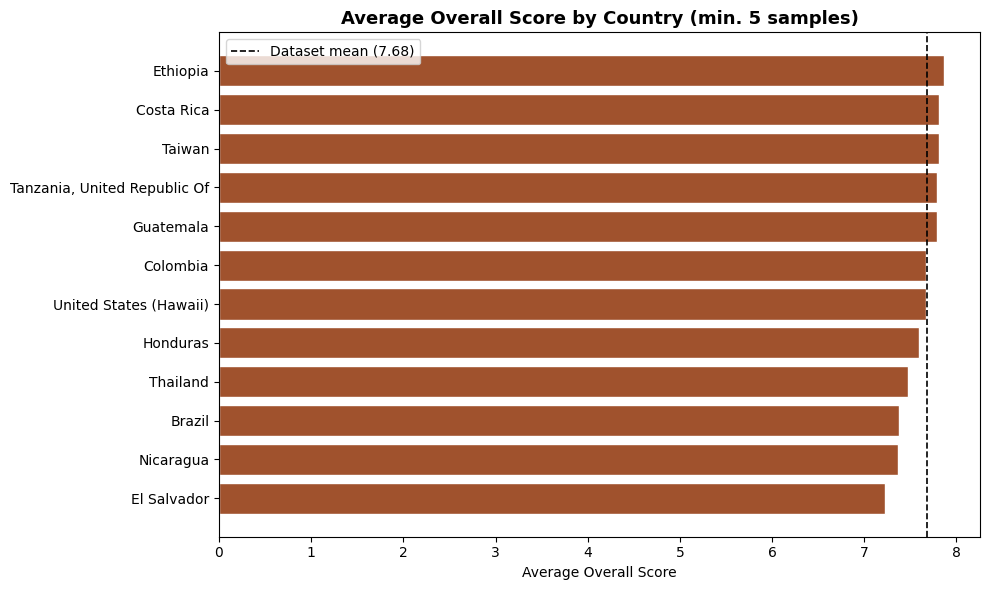


Average Overall by Country:
Country
Ethiopia                        7.863
Costa Rica                      7.814
Taiwan                          7.807
Tanzania, United Republic Of    7.792
Guatemala                       7.786
Colombia                        7.674
United States (Hawaii)          7.666
Honduras                        7.591
Thailand                        7.479
Brazil                          7.375
Nicaragua                       7.370
El Salvador                     7.227
Name: Overall, dtype: float64


In [ ]:
# Only keep countries with at least 5 samples for reliable averages
country_counts = df['Country'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

country_avg = (
    df[df['Country'].isin(valid_countries)]
    .groupby('Country')['Overall']
    .mean()
    .sort_values(ascending=True)
    .round(3)
)

plt.figure(figsize=(10, 6))
bars = plt.barh(country_avg.index, country_avg.values, color='sienna', edgecolor='white')
plt.axvline(x=df['Overall'].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Dataset mean ({df["Overall"].mean():.2f})')
plt.xlabel('Average Overall Score')
plt.title('Average Overall Score by Country (min. 5 samples)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("\nAverage Overall by Country:")
print(country_avg.sort_values(ascending=False))

## Step 5: Processing Method vs Sensory Scores

In [ ]:
# Simplify processing method labels first
def simplify_processing(value):
    value = str(value).lower().strip()
    if 'washed' in value or 'lavado' in value:
        return 'Washed'
    elif 'honey' in value:
        return 'Honey'
    elif 'natural' in value or 'dry' in value:
        return 'Natural'
    else:
        return 'Other'

df['Processing Simple'] = df['Processing Method'].apply(simplify_processing)

sensory_6 = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']

process_avg = df.groupby('Processing Simple')[sensory_6].mean().round(3)

print("Average sensory scores by Processing Method:")
print(process_avg)
print("\nSample counts:")
print(df['Processing Simple'].value_counts())

Average sensory scores by Processing Method:
                   Aroma  Flavor  Aftertaste  Acidity   Body  Balance
Processing Simple                                                    
Honey              7.698   7.753       7.625    7.698  7.629    7.626
Natural            7.734   7.748       7.608    7.684  7.639    7.646
Other              7.810   7.787       7.690    7.833  7.643    7.713
Washed             7.716   7.739       7.587    7.683  7.644    7.643

Sample counts:
Processing Simple
Washed     127
Natural     47
Honey       26
Other        7
Name: count, dtype: int64


## Step 6: Visualise Processing Method vs Sensory Scores

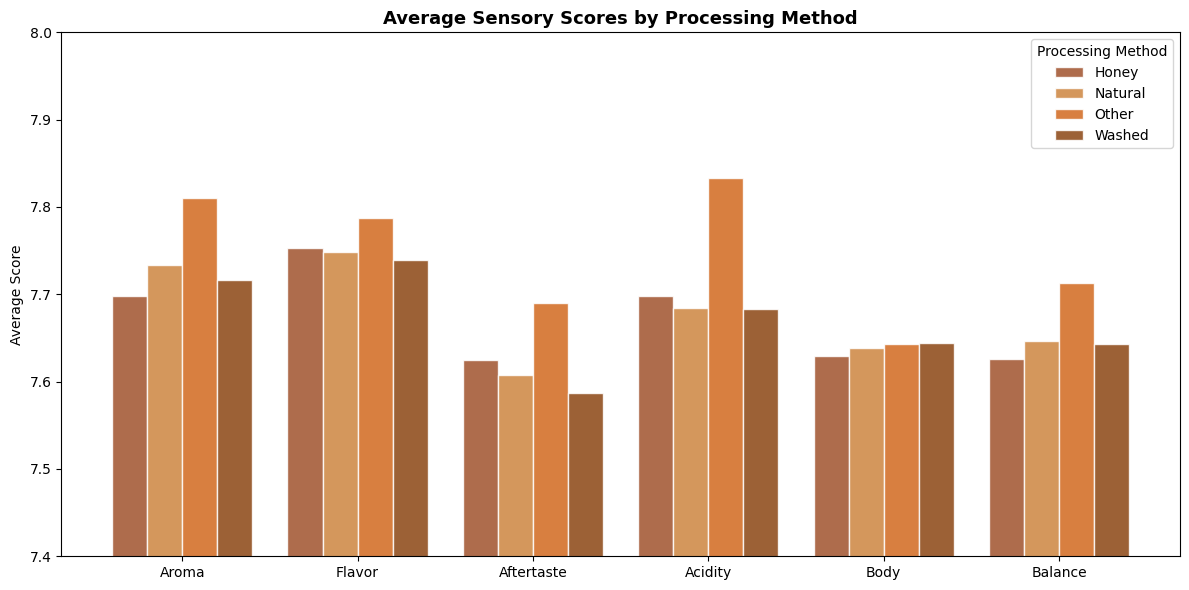

In [ ]:
process_avg_plot = df.groupby('Processing Simple')[sensory_6].mean().round(3)

x = np.arange(len(sensory_6))
width = 0.2
methods = process_avg_plot.index.tolist()
colors = ['sienna', 'peru', 'chocolate', 'saddlebrown']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (method, color) in enumerate(zip(methods, colors)):
    ax.bar(x + i * width, process_avg_plot.loc[method], width,
           label=method, color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(sensory_6)
ax.set_ylabel('Average Score')
ax.set_title('Average Sensory Scores by Processing Method',
             fontsize=13, fontweight='bold')
ax.legend(title='Processing Method')
ax.set_ylim(7.4, 8.0)
plt.tight_layout()
plt.show()

## Step 7: Moisture Percentage vs Overall Score

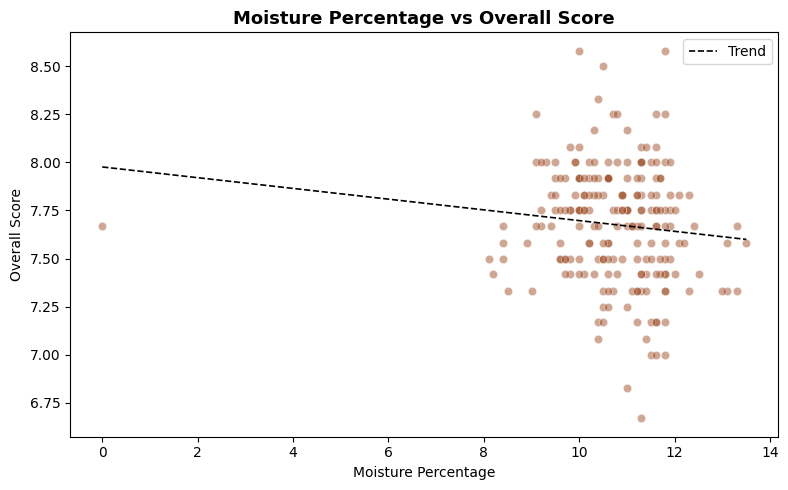

Correlation between Moisture and Overall:
-0.114


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Moisture Percentage'], df['Overall'],
            color='sienna', alpha=0.5, edgecolors='white', linewidth=0.5)

# Add a trend line
z = np.polyfit(df['Moisture Percentage'].dropna(),
               df.loc[df['Moisture Percentage'].notna(), 'Overall'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Moisture Percentage'].min(), df['Moisture Percentage'].max(), 100)
plt.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.2, label='Trend')

plt.xlabel('Moisture Percentage')
plt.ylabel('Overall Score')
plt.title('Moisture Percentage vs Overall Score', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("Correlation between Moisture and Overall:")
print(round(df['Moisture Percentage'].corr(df['Overall']), 3))

## Step 8: Defects vs Overall Score

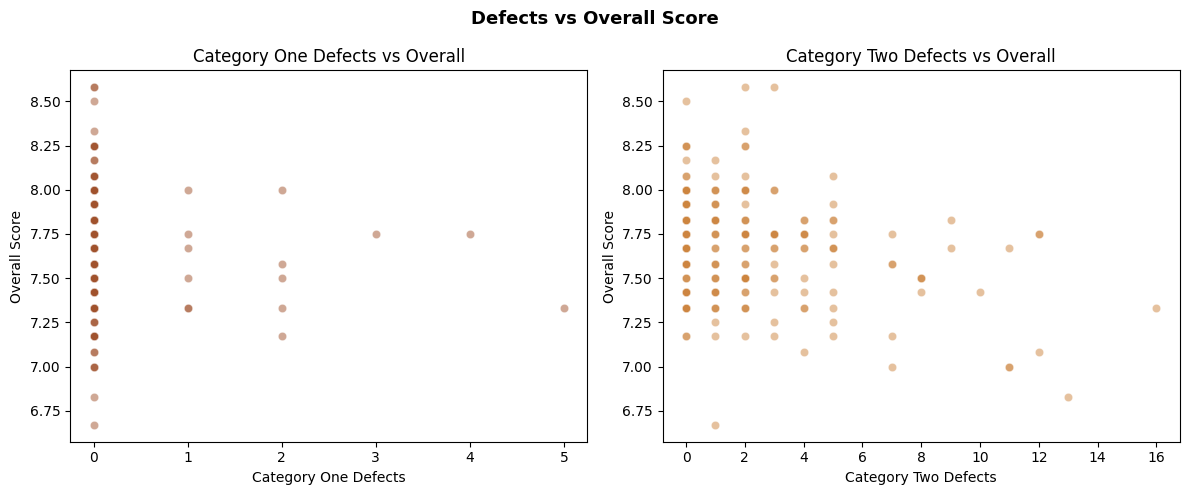

Correlation - Category One Defects vs Overall: -0.089
Correlation - Category Two Defects vs Overall: -0.312


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Category One Defects
axes[0].scatter(df['Category One Defects'], df['Overall'],
                color='sienna', alpha=0.5, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Category One Defects')
axes[0].set_ylabel('Overall Score')
axes[0].set_title('Category One Defects vs Overall')

# Category Two Defects
axes[1].scatter(df['Category Two Defects'], df['Overall'],
                color='peru', alpha=0.5, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Category Two Defects')
axes[1].set_ylabel('Overall Score')
axes[1].set_title('Category Two Defects vs Overall')

plt.suptitle('Defects vs Overall Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation - Category One Defects vs Overall:",
      round(df['Category One Defects'].corr(df['Overall']), 3))
print("Correlation - Category Two Defects vs Overall:",
      round(df['Category Two Defects'].corr(df['Overall']), 3))

## Step 9: Altitude vs Overall Score

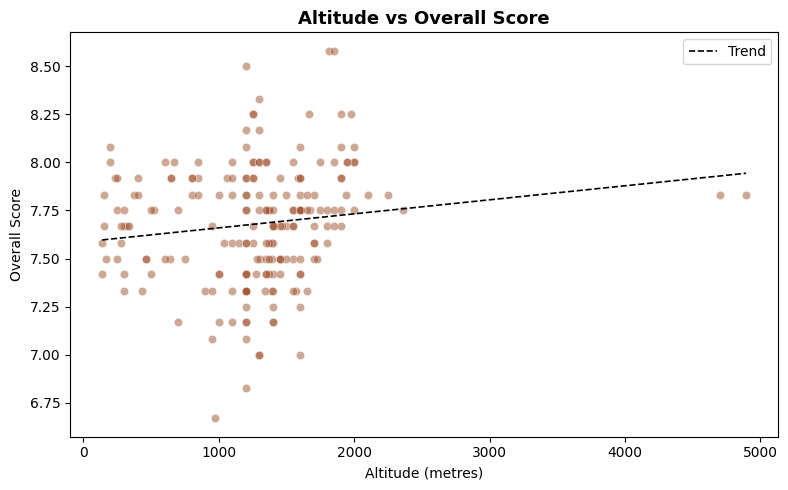

Correlation - Altitude vs Overall: 0.143
Rows used after cleaning altitude: 203
Rows dropped (missing or extreme): 4


In [ ]:
# Clean altitude - convert ranges to midpoint
def clean_altitude(value):
    try:
        value = str(value).strip()
        if '-' in value:
            low, high = value.split('-')
            return (float(low) + float(high)) / 2
        return float(value)
    except:
        return np.nan

df['Altitude Clean'] = df['Altitude'].apply(clean_altitude)

# Remove extreme outliers (likely data entry errors)
df_alt = df[df['Altitude Clean'] < 5000].copy()

plt.figure(figsize=(8, 5))
plt.scatter(df_alt['Altitude Clean'], df_alt['Overall'],
            color='sienna', alpha=0.5, edgecolors='white', linewidth=0.5)

z = np.polyfit(df_alt['Altitude Clean'].dropna(),
               df_alt.loc[df_alt['Altitude Clean'].notna(), 'Overall'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_alt['Altitude Clean'].min(), df_alt['Altitude Clean'].max(), 100)
plt.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.2, label='Trend')

plt.xlabel('Altitude (metres)')
plt.ylabel('Overall Score')
plt.title('Altitude vs Overall Score', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("Correlation - Altitude vs Overall:",
      round(df_alt['Altitude Clean'].corr(df_alt['Overall']), 3))
print("Rows used after cleaning altitude:", len(df_alt))
print("Rows dropped (missing or extreme):", len(df) - len(df_alt))

## EDA Summary — Key Findings

The table below summarises the correlation of each feature with the Overall sensory score.

| Feature | Correlation with Overall | Verdict |
|---|---|---|
| Flavor | 0.88 | Very strong — primary driver |
| Balance | 0.88 | Very strong — primary driver |
| Aftertaste | 0.87 | Very strong |
| Acidity | 0.84 | Strong |
| Aroma | 0.80 | Strong |
| Body | 0.77 | Moderate |
| Category Two Defects | -0.312 | Moderate negative |
| Altitude | 0.143 | Weak |
| Moisture | -0.114 | Weak |
| Category One Defects | -0.089 | Negligible |

**Key takeaway:** Sensory attributes are the real drivers of quality. Physical and environmental features have weak individual signal. This justifies building a regression model using sensory features to predict Overall — and explains why a multi-feature model outperforms any single physical measurement.

# Part 2 — Regression Model

## Step 1: Feature Selection
Select only the columns we need for modelling. No cleaning yet — just isolating our working dataframe.

In [ ]:
# Define features and target
target = 'Overall'

sensory_features = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']

physical_features = ['Moisture Percentage', 'Altitude Clean',
                     'Category One Defects', 'Category Two Defects']

categorical_features = ['Country', 'Processing Simple']

all_features = sensory_features + physical_features + categorical_features

# Create working dataframe with only what we need
model_df = df[all_features + [target]].copy()

print("Working dataframe shape:", model_df.shape)
print("\nFeatures selected:")
print("  Sensory:    ", sensory_features)
print("  Physical:   ", physical_features)
print("  Categorical:", categorical_features)
print("\nTarget:", target)
print("\nFirst 3 rows:")
print(model_df.head(3))

Working dataframe shape: (207, 13)

Features selected:
  Sensory:     ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
  Physical:    ['Moisture Percentage', 'Altitude Clean', 'Category One Defects', 'Category Two Defects']
  Categorical: ['Country', 'Processing Simple']

Target: Overall

First 3 rows:
   Aroma  Flavor  Aftertaste  Acidity  Body  Balance  Moisture Percentage  \
0   8.58    8.50        8.42     8.58  8.25     8.42                 11.8   
1   8.50    8.50        7.92     8.00  7.92     8.25                 10.5   
2   8.33    8.42        8.08     8.17  7.92     8.17                 10.4   

   Altitude Clean  Category One Defects  Category Two Defects   Country  \
0          1815.0                     0                     3  Colombia   
1          1200.0                     0                     0    Taiwan   
2          1300.0                     0                     2      Laos   

  Processing Simple  Overall  
0            Washed     8.58  
1        

## Step 2: Check Missing Values

In [ ]:
print("Missing values per column:")
print(model_df.isnull().sum())

Missing values per column:
Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Moisture Percentage     0
Altitude Clean          3
Category One Defects    0
Category Two Defects    0
Country                 0
Processing Simple       0
Overall                 0
dtype: int64


## Step 3: Handle Missing Values

In [ ]:
# Fill 3 missing altitude values with median
altitude_median = model_df['Altitude Clean'].median()
model_df['Altitude Clean'] = model_df['Altitude Clean'].fillna(altitude_median)

print("Missing values after fix:")
print(model_df.isnull().sum())
print(f"\nAltitude median used for fill: {altitude_median}m")

Missing values after fix:
Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Moisture Percentage     0
Altitude Clean          0
Category One Defects    0
Category Two Defects    0
Country                 0
Processing Simple       0
Overall                 0
dtype: int64

Altitude median used for fill: 1301.25m


## Step 4: Check Outliers in Physical Features

In [ ]:
print("=== Moisture Percentage ===")
print(model_df['Moisture Percentage'].describe().round(3))
print("\nSuspect values (0% moisture):")
print(model_df[model_df['Moisture Percentage'] == 0][['Moisture Percentage', 'Country', 'Overall']])

print("\n=== Altitude Clean ===")
print(model_df['Altitude Clean'].describe().round(3))
print("\nSuspect values (above 4000m):")
print(model_df[model_df['Altitude Clean'] > 4000][['Altitude Clean', 'Country', 'Overall']])

print("\n=== Category Two Defects ===")
print(model_df['Category Two Defects'].describe().round(3))
print("\nValue counts:")
print(model_df['Category Two Defects'].value_counts().sort_index())

=== Moisture Percentage ===
count    207.000
mean      10.735
std        1.247
min        0.000
25%       10.100
50%       10.800
75%       11.500
max       13.500
Name: Moisture Percentage, dtype: float64

Suspect values (0% moisture):
     Moisture Percentage     Country  Overall
125                  0.0  Costa Rica     7.67

=== Altitude Clean ===
count     207.000
mean     1292.025
std       664.426
min       139.000
25%      1020.000
50%      1301.250
75%      1600.000
max      5400.000
Name: Altitude Clean, dtype: float64

Suspect values (above 4000m):
     Altitude Clean    Country  Overall
47           4700.0  Guatemala     7.83
60           4895.0  Guatemala     7.83
182          5400.0    Vietnam     7.33

=== Category Two Defects ===
count    207.000
mean       2.251
std        2.950
min        0.000
25%        0.000
50%        1.000
75%        3.000
max       16.000
Name: Category Two Defects, dtype: float64

Value counts:
Category Two Defects
0     74
1     34
2     37
3  

## Step 5: Fix Outliers

In [ ]:
# Fix moisture = 0 (impossible value)
moisture_median = model_df[model_df['Moisture Percentage'] > 0]['Moisture Percentage'].median()
model_df.loc[model_df['Moisture Percentage'] == 0, 'Moisture Percentage'] = moisture_median
print(f"Moisture 0.0 fixed with median: {moisture_median}%")

# Fix altitude > 4000m (physically impossible for coffee farms)
altitude_median = model_df[model_df['Altitude Clean'] <= 4000]['Altitude Clean'].median()
model_df.loc[model_df['Altitude Clean'] > 4000, 'Altitude Clean'] = altitude_median
print(f"Altitude outliers fixed with median: {altitude_median}m")

print("\nVerification:")
print(f"Moisture min: {model_df['Moisture Percentage'].min()}")
print(f"Altitude max: {model_df['Altitude Clean'].max()}")

Moisture 0.0 fixed with median: 10.850000000000001%
Altitude outliers fixed with median: 1300.625m

Verification:
Moisture min: 8.1
Altitude max: 2361.0


## Step 6: Clean Country Column and Encode Categoricals

In [ ]:
# Group countries with fewer than 5 samples into 'Other'
country_counts = model_df['Country'].value_counts()
rare_countries = country_counts[country_counts < 5].index.tolist()

print("Countries grouped into 'Other':")
print(rare_countries)

model_df['Country'] = model_df['Country'].apply(
    lambda x: 'Other' if x in rare_countries else x
)

print("\nCountry counts after grouping:")
print(model_df['Country'].value_counts())

Countries grouped into 'Other':
['Mexico', 'Peru', 'Vietnam', 'Laos', 'Uganda', 'Indonesia', 'Kenya', 'Panama', 'Madagascar', 'Myanmar']

Country counts after grouping:
Country
Taiwan                          61
Other                           27
Guatemala                       21
Colombia                        19
Honduras                        13
Thailand                        12
Ethiopia                        11
Brazil                          10
Costa Rica                       8
El Salvador                      7
Nicaragua                        7
Tanzania, United Republic Of     6
United States (Hawaii)           5
Name: count, dtype: int64


## Final Check: Cleaned Data Overview

In [ ]:
print("Shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isnull().sum())
print("\nNumerical summary:")
print(model_df.describe().round(3))
print("\nFirst 5 rows:")
print(model_df.head())

Shape: (207, 13)

Missing values:
Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Moisture Percentage     0
Altitude Clean          0
Category One Defects    0
Category Two Defects    0
Country                 0
Processing Simple       0
Overall                 0
dtype: int64

Numerical summary:
         Aroma   Flavor  Aftertaste  Acidity     Body  Balance  \
count  207.000  207.000     207.000  207.000  207.000  207.000   
mean     7.721    7.745       7.600    7.690    7.641    7.644   
std      0.288    0.280       0.276    0.260    0.233    0.256   
min      6.500    6.750       6.670    6.830    6.830    6.670   
25%      7.580    7.580       7.420    7.500    7.500    7.500   
50%      7.670    7.750       7.580    7.670    7.670    7.670   
75%      7.920    7.920       7.750    7.875    7.750    7.790   
max      8.580    8.500       8.420    8.580    8.250    8.420   



## Step 8: Encode Categorical Features

In [ ]:
model_df_encoded = pd.get_dummies(model_df,
                                   columns=['Country', 'Processing Simple'],
                                   drop_first=False)

print("Shape after encoding:", model_df_encoded.shape)
print("\nAll columns:")
print(model_df_encoded.columns.tolist())

Shape after encoding: (207, 28)

All columns:
['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Moisture Percentage', 'Altitude Clean', 'Category One Defects', 'Category Two Defects', 'Overall', 'Country_Brazil', 'Country_Colombia', 'Country_Costa Rica', 'Country_El Salvador', 'Country_Ethiopia', 'Country_Guatemala', 'Country_Honduras', 'Country_Nicaragua', 'Country_Other', 'Country_Taiwan', 'Country_Tanzania, United Republic Of', 'Country_Thailand', 'Country_United States (Hawaii)', 'Processing Simple_Honey', 'Processing Simple_Natural', 'Processing Simple_Other', 'Processing Simple_Washed']


## Step 9: Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = model_df_encoded.drop(columns=['Overall'])
y = model_df_encoded['Overall']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)
print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

X_train shape: (165, 27)
X_test shape:  (42, 27)
y_train shape: (165,)
y_test shape:  (42,)

Training samples: 165
Testing samples:  42


## Step 10: Train Random Forest Regressor

# 9. Random Forest Regression — Single Train-Test Split

The first model trained in Version 1 is a Random Forest Regressor.

The dataset is split into training and testing subsets using an 80/20 split. The model is trained on the training set and evaluated on the test set.

## Why this step matters

This step gives an initial estimate of model performance, but it only tests the model on one fixed test sample. Because the dataset contains only 207 rows, the result can be strongly affected by which rows happen to be placed in the test set.

Therefore, this result should be interpreted as an initial check, not final proof that the regression model works reliably.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=== Random Forest Regressor Results ===")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")

=== Random Forest Regressor Results ===
R² Score:  0.7925
MAE:       0.0969
RMSE:      0.1250


## Step 11: Cross Validation Check

# 10. Version 1 Cross-Validation — Negative CV Result

This is the most important evaluation step in Version 1.

The notebook applies:

```python
cross_val_score(rf_model, X, y, cv=5, scoring='r2')
```

In Scikit-learn, using `cv=5` for regression applies 5-fold K-Fold cross-validation without shuffling the dataset first.

## Why this matters

Because the dataset is small and may not be randomly distributed row-by-row, each fold can contain a different distribution of:

- coffee quality scores,
- countries of origin,
- processing methods,
- sensory score ranges.

This creates unstable folds. The model may train on one type of distribution and test on another. That is why the cross-validation scores become negative.

## Meaning of negative R²

A negative R² score means the model performs worse than a simple baseline that predicts the mean value of the target.

In Version 1, this does not automatically mean regression is impossible. It means the first validation setup is unstable and too harsh for this small dataset.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print("=== 5-Fold Cross Validation R² Scores ===")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")

print(f"\nMean R²:  {cv_scores.mean():.4f}")
print(f"Std R²:   {cv_scores.std():.4f}")

=== 5-Fold Cross Validation R² Scores ===
  Fold 1: -1.4749
  Fold 2: -0.6712
  Fold 3: -0.6944
  Fold 4: -0.8191
  Fold 5: -1.0944

Mean R²:  -0.9508
Std R²:   0.3022


# 11. Version 1 Model Comparison

To check whether the poor cross-validation result is caused only by Random Forest, Version 1 compares multiple regression algorithms using the same validation approach.

Models tested:

- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor

## Purpose of this comparison

If all models perform poorly under the same cross-validation setup, then the issue is not only the selected algorithm. It suggests that the dataset, fold distribution, feature structure, or validation method is causing the instability.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("=== 5-Fold Cross Validation R² Scores ===\n")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"{name}")
    print(f"  Mean R²: {scores.mean():.4f}  Std: {scores.std():.4f}")

=== 5-Fold Cross Validation R² Scores ===

Linear Regression
  Mean R²: -0.1079  Std: 0.7222
Ridge Regression
  Mean R²: -0.0006  Std: 0.5965
Random Forest
  Mean R²: -0.9508  Std: 0.3022
Gradient Boosting
  Mean R²: -0.6660  Std: 0.1962


# 12. Version 1 Findings and Interpretation

## 12.1 What Version 1 showed

Version 1 produced two very different outcomes:

| Evaluation Method | Result | Interpretation |
|---|---|---|
| Single train-test split | Strong positive R² | The model performed well on one fixed split |
| 5-fold cross-validation | Negative R² values | The model did not generalise consistently across folds |

This difference created the main modelling problem in Version 1.

---

## 12.2 Why Version 1 produced negative CV values

The negative cross-validation values were mainly caused by the following issues:

### 1. No shuffling in cross-validation


### 2. Very small dataset


### 3. Narrow target range


### 4. High correlation between sensory variables


### 5. Random Forest overfitting risk


## 12.3 Final conclusion for Version 1


